In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import ast
from collections import defaultdict
import os
import sys
import json
import textwrap
import importlib
from itertools import product as iproduct
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
# Usage
BASE_DIR = "../experiment11[time-depol-trotter-vs-standard]/data"
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)
EXACT_SOL :float = -7.29622981055876

In [3]:
RAW_SIM_DATA.keys()

dict_keys(['time-depol-trotter', 'time-depol', 'time-depol-trotter_delt0.03'])

In [4]:
RAW_SIM_DATA["time-depol-trotter"].keys()

dict_keys(['ZNE', 'VQE', 'VQE_noiseoff'])

In [5]:
def process_simulation_data(raw: dict) -> dict:
    processed = {}

    # Iterate over "time-depol", "time-depol-trotter", etc.
    # We look inside the "data" folder directly if it exists
    experiments = raw.get("data", raw)

    for category_key, category_contents in sorted(experiments.items()):
        
        # Dictionary to hold results for this specific experiment category
        category_entry = {
            "VQE": {"mean": 0.0, "std": 0.0},
            "VQE_noiseoff": {"mean": 0.0, "std": 0.0},
            "ZNE": {}
        }

        for folder_name, folder_contents in category_contents.items():
            
            # --- 1. Handle ZNE (ric2, ric4, etc.) ---
            if folder_name == "ZNE":
                for label, runs in sorted(folder_contents.items()):
                    ext_vals, noises, exp_vals = [], [], []
                    tmax = None

                    for run_key, run in runs.items():
                        if run is None or "REDUNDANT" in run_key: continue
                        try:
                            tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]
                            output = run["output"]["zne_values"]
                            ext_vals.append(output["extrapolated_value"])
                            noises.append(output["others"]["sorted_noise"])
                            exp_vals.append(output["others"]["sorted_expectation_vals"])
                        except (KeyError, TypeError): continue

                    if ext_vals:
                        category_entry["ZNE"][label] = {
                            "tmax": tmax,
                            "mean": float(np.mean(ext_vals)),
                            "std": float(np.std(ext_vals)),
                            "sorted_noise": noises,
                            "sorted_expvals": exp_vals,
                        }

            # --- 2. Handle VQE and VQE_noiseoff separately ---
            elif folder_name in ["VQE", "VQE_noiseoff"]:
                costs = []
                # Iterate through the runs in the VQE or VQE_noiseoff folder
                for run_key, run in folder_contents.items():
                    if run is not None and "REDUNDANT" not in run_key:
                        try:
                            costs.append(run["output"]["optimized_minimum_cost"][0])
                        except (KeyError, IndexError, TypeError): continue
                
                if costs:
                    category_entry[folder_name] = {
                        "mean": float(np.mean(costs)),
                        "std": float(np.std(costs))
                    }

        processed[category_key] = category_entry

    return processed

In [6]:
PROCESSED_SIM_DATA = process_simulation_data(RAW_SIM_DATA)

for tmax, entry in sorted(PROCESSED_SIM_DATA.items()):
    print(f"\n{tmax}")
    if "VQE" in entry:
        v = entry["VQE"]
        print(f"  VQE        → mean={v['mean']:.6f}  std={v['std']:.6f}")
    if "ZNE" in entry:
        for label, z in entry["ZNE"].items():
            print(f"  ZNE/{label:6s} → mean={z['mean']:.6f}  std={z['std']:.6f}  n={len(z['sorted_noise'])} runs")


time-depol
  VQE        → mean=-5.376872  std=0.151060
  ZNE/mul-var3-d1 → mean=-6.652335  std=0.111886  n=0 runs
  ZNE/mul-var3-d2 → mean=-7.015879  std=0.068175  n=0 runs
  ZNE/mul-var3-d3 → mean=-7.116432  std=0.038877  n=0 runs
  ZNE/mul1   → mean=-6.175960  std=0.143181  n=0 runs
  ZNE/ric2   → mean=-6.437801  std=0.124230  n=10 runs
  ZNE/ric4   → mean=-6.983444  std=0.072552  n=10 runs

time-depol-trotter
  VQE        → mean=-5.218940  std=0.131820
  ZNE/mul1   → mean=-6.025411  std=0.128558  n=0 runs
  ZNE/ric2   → mean=-6.305544  std=0.112520  n=10 runs
  ZNE/ric4   → mean=-6.901067  std=0.068562  n=10 runs

time-depol-trotter_delt0.03
  VQE        → mean=-5.211605  std=0.103071
  ZNE/ric4   → mean=-6.893149  std=0.056367  n=10 runs


In [7]:
PROCESSED_SIM_DATA.keys()

dict_keys(['time-depol', 'time-depol-trotter', 'time-depol-trotter_delt0.03'])

In [8]:
# 1. Access the noiseoff folder from RAW_SIM_DATA
noiseoff_folder = RAW_SIM_DATA["time-depol-trotter"].get("VQE_noiseoff", {})

# 2. Extract values from all valid runs
noiseoff_values = []
for run_key, run in noiseoff_folder.items():
    if run is not None and "REDUNDANT" not in run_key:
        try:
            # Extract the first element of the optimized cost list
            cost = run["output"]["optimized_minimum_cost"][0]
            noiseoff_values.append(cost)
        except (KeyError, IndexError, TypeError):
            continue

# 3. Compute Stats
if noiseoff_values:
    noiseoff_mean = float(np.mean(noiseoff_values))
    noiseoff_std  = float(np.std(noiseoff_values))
else:
    noiseoff_mean, noiseoff_std = 0.0, 0.0

print(f"Noise-free Mean: {noiseoff_mean:.6f}")
print(f"Noise-free Std:  {noiseoff_std:.6f}")

Noise-free Mean: -7.284018
Noise-free Std:  0.012635


In [9]:
import numpy as np
import warnings

def process_for_master_plotting(raw_data: dict) -> dict:
    processed = {}
    # Access the 'data' folder from your experiment tree
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        processed[exp_name] = {}
        
        # --- 1. Aggregating VQE_noiseoff (The Star Marker) ---
        nf_folder = content.get("VQE_noiseoff", {})
        nf_costs = []
        for k, run in nf_folder.items():
            if run and "REDUNDANT" not in k and "output" in run:
                try:
                    nf_costs.append(run["output"]["optimized_minimum_cost"][0])
                except (KeyError, IndexError, TypeError):
                    continue
        
        nf_stats = {
            "mean": float(np.mean(nf_costs)) if nf_costs else None,
            "std":  float(np.std(nf_costs)) if nf_costs else None
        }

        # --- 2. Processing ZNE Subfolders (mul1, ric2, etc.) ---
        zne_folder = content.get("ZNE", {})
        
        # If mul1 is missing, ensure the key exists in the raw zne_folder
        for label, runs in zne_folder.items():
            ext_vals, all_y_curves = [], []
            noise_levels = None
            
            for k, run in runs.items():
                # Skip nulls or redundant files
                if not run or "REDUNDANT" in k or "output" not in run: 
                    continue
                
                # Safely navigate the nested structure
                zne_vals = run["output"].get("zne_values", {})
                others = zne_vals.get("others", {})
                
                # Fallback logic: check 'others' first, then 'zne_values' directly
                current_y = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
                current_n = others.get("sorted_noise") or zne_vals.get("sorted_noise")
                ext_val = zne_vals.get("extrapolated_value")

                if current_y and current_n and ext_val is not None:
                    ext_vals.append(ext_val)
                    all_y_curves.append(current_y)
                    if noise_levels is None:
                        noise_levels = current_n
                else:
                    # Debug print to see which file is failing the check
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: Missing required keys.")

            # --- 3. Final Formatting for master.py ---
            if ext_vals and all_y_curves:
                y_array = np.array(all_y_curves)
                processed[exp_name][label] = {
                    "noise_type":     "depolarizing", 
                    "exact_sol":      EXACT_SOL, # Global variable you defined
                    "sorted_noise":   noise_levels,
                    "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                    "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                    "zne_mean":       float(np.mean(ext_vals)),
                    "zne_std":        float(np.std(ext_vals)),
                    "mean_noise_off": nf_stats["mean"],
                    "std_noise_off":  nf_stats["std"]
                }
            else:
                print(f"❌ Failed to process ZNE label: {label} (No valid runs found)")

    return processed

In [10]:
results = process_for_master_plotting(RAW_SIM_DATA)

⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#3_20260325_152928_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#6_20260325_153120_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#1_20260325_152806_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#7_20260325_153155_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#10_20260325_153342_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#9_20260325_153307_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_tro

In [11]:
figsize = (8, 5)

KeyError: 'unmitigated'

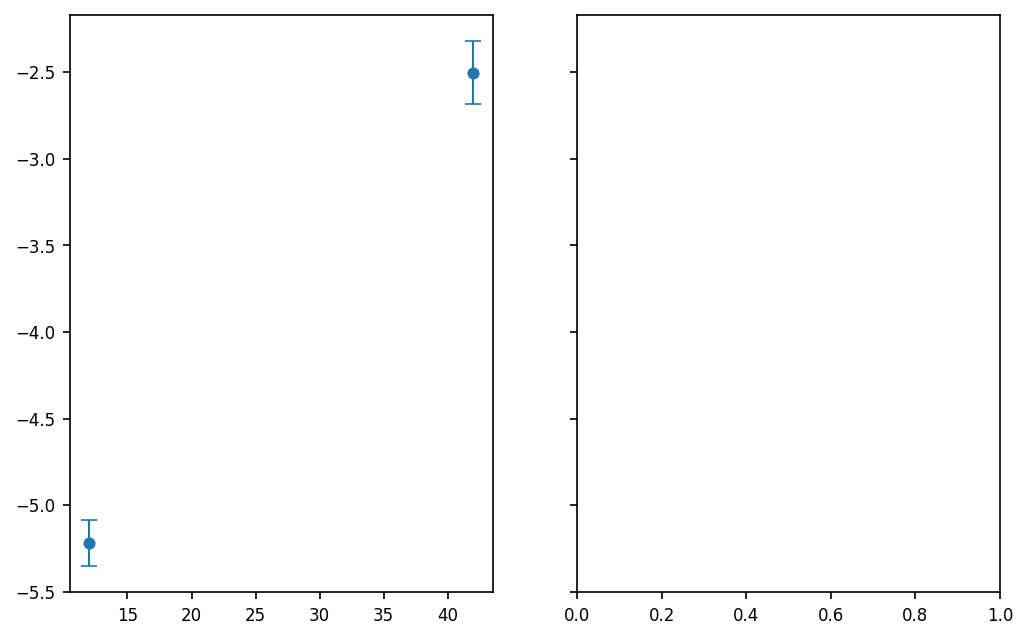

In [12]:
# 1. Get the processed data

exp_data = results["time-depol-trotter"]

# 2. Prepare the list for subplots
data_to_plot = [exp_data["ric2"], exp_data["ric4"]]

# 3. Use the master.py function
COLORS = {
    "noisy": "#1f77b4", "zne": "#ff7f0e", 
    "exact": "#d62728", "noise_free": "#9467bd"
}

plot_multi_zne(
    data_list=data_to_plot,
    plot_colors=COLORS,
    plot_titles=["Trotter: (a) Richardson Order 2", "(b) Richardson Order 4"],
    ncols=2,
    figsize=figsize,
    output_dir="./reports",
    plot_file_name="comparison_ric2_ric4",
    global_legend=True,
    show_plot = False,
    
)

⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#3_20260325_152928_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#6_20260325_153120_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#1_20260325_152806_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#7_20260325_153155_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#10_20260325_153342_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#9_20260325_153307_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_tro

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in './reports' folder): comparison_ric2_ric4.eps


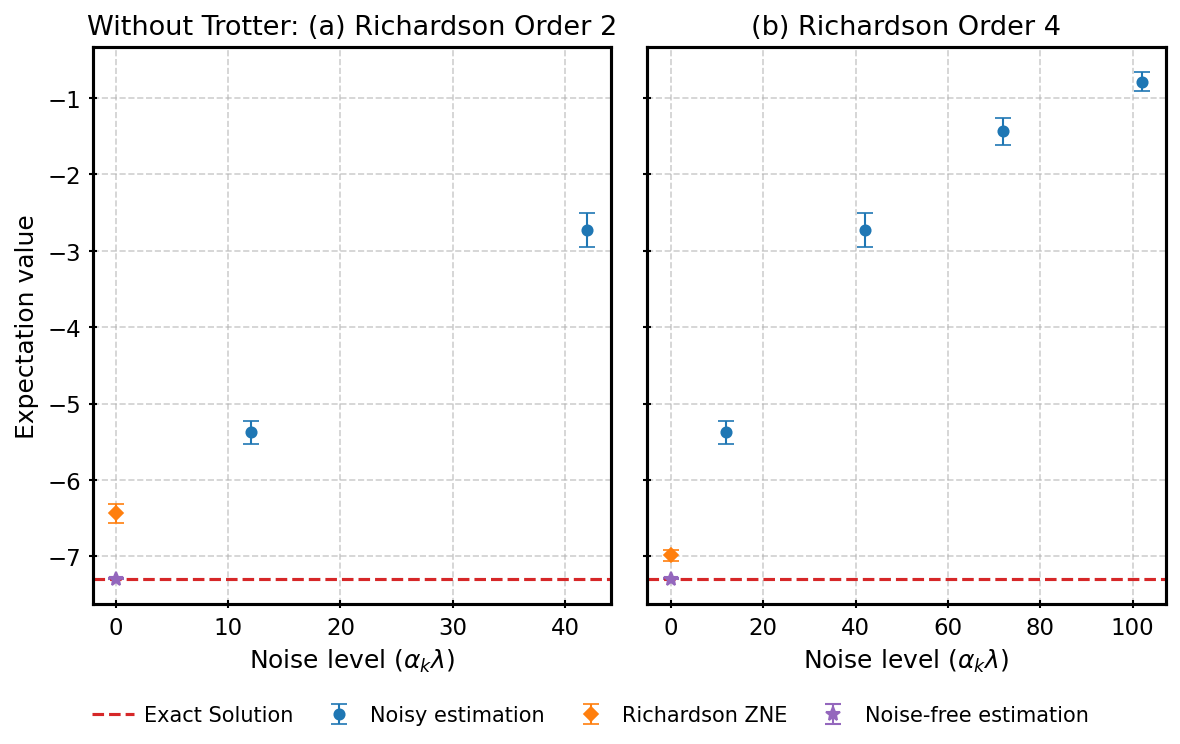

In [ ]:
# 1. Get the processed data
results = process_for_master_plotting(RAW_SIM_DATA)
exp_data = results["time-depol"]

# 2. Prepare the list for subplots
data_to_plot = [exp_data["ric2"], exp_data["ric4"]]

# 3. Use the master.py function
COLORS = {
    "noisy": "#1f77b4", "zne": "#ff7f0e", 
    "exact": "#d62728", "noise_free": "#9467bd"
}

plot_multi_zne(
    data_list=data_to_plot,
    plot_colors=COLORS,
    plot_titles=["Without Trotter: (a) Richardson Order 2", "(b) Richardson Order 4"],
    ncols=2,
    figsize=figsize,
    output_dir="./reports",
    plot_file_name="comparison_ric2_ric4",
    global_legend=True,
    show_plot = False
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


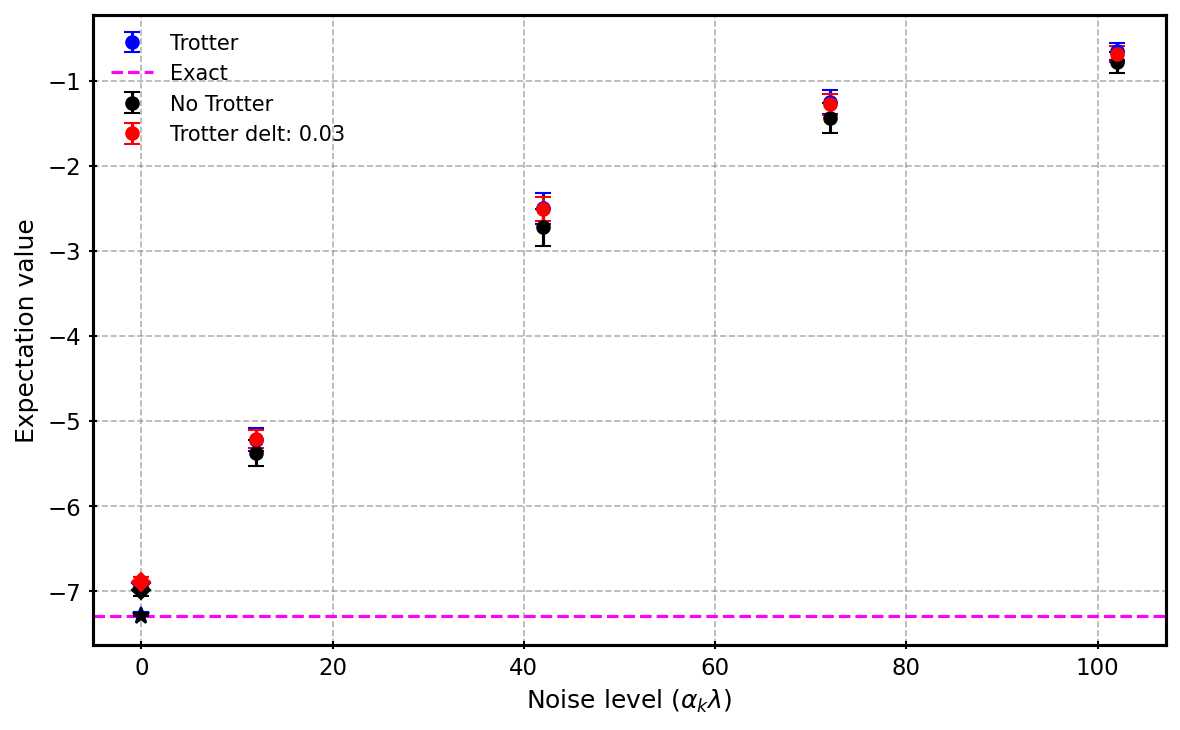

In [ ]:
# 1. Get the processed data

data_trotter = results["time-depol-trotter"]
data_no_trotter = results["time-depol"]
data_trotter_delt0_03 = results["time-depol-trotter_delt0.03"]

# 2. Prepare the list for subplots
data_to_plot = [data_trotter["ric4"], data_no_trotter["ric4"], data_trotter_delt0_03["ric4"]]

# 3. Use the master.py function
COLORS =  [
    "#0000ff", 
    "black",
    "#ff0000" 
]
plot_titles=[
    "Trotter",
    "No Trotter",
    "Trotter delt: 0.03"
]
plot_single_zne_imposed(
    data_list=data_to_plot,
    plot_colors={"exact": "magenta"},
    #plot_colors=COLORS,
    plot_titles=plot_titles,
     dataset_colors=COLORS,
    figsize=figsize,
    output_dir="./reports",
    plot_file_name="comparison_ric2_ric4",
    #global_legend=True,
    show_plot = False,
    
)

In [ ]:
data_to_plot[0].keys()

dict_keys(['noise_type', 'exact_sol', 'sorted_noise', 'mean_exp_vals', 'std_exp_vals', 'zne_mean', 'zne_std', 'mean_noise_off', 'std_noise_off'])

---

### Multivariate

Generating linearly-independent identity factors for unitary folding.

In [ ]:
l, d, Delta = 4, 3, 1
ms = [m for m in iproduct(range(d+1), repeat=l) if sum(m) <= d]

lambdas = [[1 + Delta*mi for mi in m] for m in ms]
# [(1,1,1),(1,1,2),(1,1,3),(1,2,1),(1,2,2),(1,3,1),(2,1,1),(2,1,2),(2,2,1),(3,1,1)]
# cond(A) ≈ 30  ← much better
print("Linearly independent identity factors:")
print("Length: ", len(lambdas))
print(lambdas)

Linearly independent identity factors:
Length:  35
[[1, 1, 1, 1], [1, 1, 1, 2], [1, 1, 1, 3], [1, 1, 1, 4], [1, 1, 2, 1], [1, 1, 2, 2], [1, 1, 2, 3], [1, 1, 3, 1], [1, 1, 3, 2], [1, 1, 4, 1], [1, 2, 1, 1], [1, 2, 1, 2], [1, 2, 1, 3], [1, 2, 2, 1], [1, 2, 2, 2], [1, 2, 3, 1], [1, 3, 1, 1], [1, 3, 1, 2], [1, 3, 2, 1], [1, 4, 1, 1], [2, 1, 1, 1], [2, 1, 1, 2], [2, 1, 1, 3], [2, 1, 2, 1], [2, 1, 2, 2], [2, 1, 3, 1], [2, 2, 1, 1], [2, 2, 1, 2], [2, 2, 2, 1], [2, 3, 1, 1], [3, 1, 1, 1], [3, 1, 1, 2], [3, 1, 2, 1], [3, 2, 1, 1], [4, 1, 1, 1]]


In [ ]:
[[0, 0, 0, 0], *lambdas[:len(lambdas)-1]][:20]

[[0, 0, 0, 0],
 [1, 1, 1, 1],
 [1, 1, 1, 2],
 [1, 1, 1, 3],
 [1, 1, 1, 4],
 [1, 1, 2, 1],
 [1, 1, 2, 2],
 [1, 1, 2, 3],
 [1, 1, 3, 1],
 [1, 1, 3, 2],
 [1, 1, 4, 1],
 [1, 2, 1, 1],
 [1, 2, 1, 2],
 [1, 2, 1, 3],
 [1, 2, 2, 1],
 [1, 2, 2, 2],
 [1, 2, 3, 1],
 [1, 3, 1, 1],
 [1, 3, 1, 2],
 [1, 3, 2, 1]]

In [ ]:
def process_single_mul(runs_dict):
    """
    Processes a specific multiplier's runs. 
    Handles variable noise vector lengths (3D or 4D).
    """
    extrap_vals = []
    dp_costs = defaultdict(list)
    exact_sol = None

    for run_key, sample in runs_dict.items():
        if sample is None or "REDUNDANT" in run_key:
            continue

        out = sample.get("output", {})
        zne_vals = out.get("zne_values", {})

        if exact_sol is None:
            exact_sol = out.get("exact_sol")

        if "extrapolated_value" in zne_vals:
            extrap_vals.append(float(zne_vals["extrapolated_value"]))

        for pt in zne_vals.get("sampled data", []):
            # Coordinates are everything BUT the last element
            coord_tuple = tuple(map(int, pt[:-1])) 
            # The last element is the cost
            cost_val = float(pt[-1])
            
            key = str(coord_tuple)
            dp_costs[key].append(cost_val)

    return {
        "mul_data": {
            "extrapolated": {
                "mean": float(np.mean(extrap_vals)) if extrap_vals else 0,
                "std":  float(np.std(extrap_vals)) if extrap_vals else 0,
            },
            "data_points": {
                key: {
                    "mean": float(np.mean(vals)),
                    "std":  float(np.std(vals)),
                }
                for key, vals in sorted(dp_costs.items())
            },
        },
        "exact_sol": exact_sol
    }


def plot_ricmul(processed, title=None, save_path=None, figsize=(10, 5)):
    exact = processed.get("exact_sol")
    label = "mul_data"

    data_points = processed[label]["data_points"]
    extrapolated = processed[label]["extrapolated"]

    # Sort keys based on the sum of the noise vector components
    sorted_keys = sorted(data_points.keys(), key=lambda k: sum(ast.literal_eval(k)))

    first_key_len = len(ast.literal_eval(sorted_keys[0]))
    zne_label = f"ZNE\n({','.join(['0']*first_key_len)})"

    x_labels = [zne_label] + sorted_keys
    x = np.arange(len(x_labels))

    means = [extrapolated["mean"]] + [data_points[k]["mean"] for k in sorted_keys]
    stds  = [extrapolated["std"]]  + [data_points[k]["std"]  for k in sorted_keys]

    means = np.array(means)
    stds  = np.array(stds)

    fig, ax = plt.subplots(figsize=figsize)

    # 1. Plot the ZNE point (index 0) with a unique color
    ax.errorbar(
        x[0], means[0], yerr=stds[0], 
        fmt="o", color="#60a5fa", ecolor="#60a5fa", 
        elinewidth=2, capsize=4, markersize=8,
        label=f"ZNE value: {means[0]:.4f} ± {stds[0]:.4f}",
        zorder=5
    )

    # 2. Plot the remaining Simulation Data points
    ax.errorbar(
        x[1:], means[1:], yerr=stds[1:], 
        fmt="o", color="red", ecolor="red", 
        elinewidth=2, capsize=4, markersize=7,
        linestyle="None",
        label="Noisy estimations",
        zorder=3
    )

    # 3. Plot the Exact Solution line if available
    if exact is not None:
        ax.axhline(exact, color="magenta", linestyle="--", linewidth=1.5,
                   label=f"Exact value: {exact:.4f}", zorder=4)

    # Visual separator
    ax.axvline(0.5, color="#666", linestyle=":", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_title(title, fontsize=12, pad=15)
    ax.set_ylabel("Expectation Value")
    ax.set_xlabel("Noise Vector (nR+nY, nCz, nU)")
    ax.grid(True, linestyle="--", alpha=0.4)
    
    # Legend placement
    ax.legend(frameon=False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.close(fig)
    return fig

{'mul_data': {'extrapolated': {'mean': -6.652334747746305, 'std': 0.11188606393472393}, 'data_points': {'(30, 10, 18)': {'mean': -1.6627783961603608, 'std': 0.19079995369571337}, '(30, 6, 18)': {'mean': -2.1916895271643453, 'std': 0.20196868455618602}, '(4, 2, 6)': {'mean': -5.376872043907548, 'std': 0.15106007040720046}, '(42, 6, 18)': {'mean': -1.768851454453881, 'std': 0.18344819503510362}, '(48, 6, 30)': {'mean': -1.3783590356697188, 'std': 0.1593612532175594}}}, 'exact_sol': -7.296229810558759}


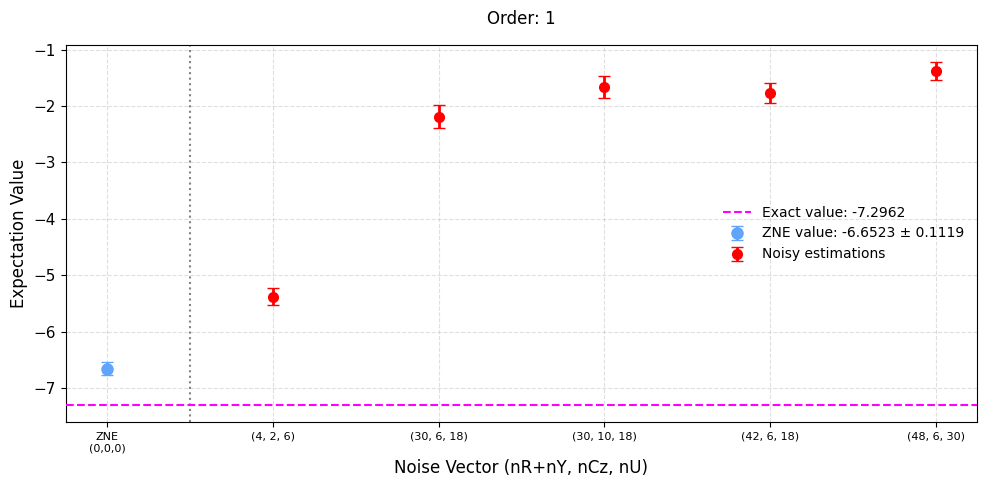

In [ ]:
# Multivariate (3 noise variable vs extrapolated value) Richardson extrapolation of order 1 
ricmul_d1 = process_single_mul(RAW_SIM_DATA["time-depol"]["ZNE"]["mul-var3-d1"])
print(ricmul_d1)
plot_ricmul(ricmul_d1, title = "Order: 1")

{'mul_data': {'extrapolated': {'mean': -7.015878975148192, 'std': 0.06817491681578404}, 'data_points': {'(30, 10, 18)': {'mean': -1.6627783961603604, 'std': 0.1907999536957133}, '(30, 14, 18)': {'mean': -1.276309401868216, 'std': 0.17307836757259829}, '(30, 6, 18)': {'mean': -2.1916895271643453, 'std': 0.20196868455618608}, '(38, 10, 18)': {'mean': -1.4944101478864282, 'std': 0.1839196866336041}, '(38, 6, 18)': {'mean': -1.9603873703857335, 'std': 0.19836064980317877}, '(4, 2, 6)': {'mean': -5.376872043907548, 'std': 0.15106007040720046}, '(42, 10, 18)': {'mean': -1.346303637933639, 'std': 0.1684381261748081}, '(42, 6, 18)': {'mean': -1.7688514544538811, 'std': 0.1834481950351038}, '(48, 10, 30)': {'mean': -1.052067744710349, 'std': 0.1425712119493919}, '(48, 6, 30)': {'mean': -1.3783590356697188, 'std': 0.15936125321755942}, '(50, 6, 18)': {'mean': -1.5842726519670303, 'std': 0.17782485235377257}, '(54, 6, 18)': {'mean': -1.4321446864811962, 'std': 0.16451871505834315}, '(56, 6, 30)':

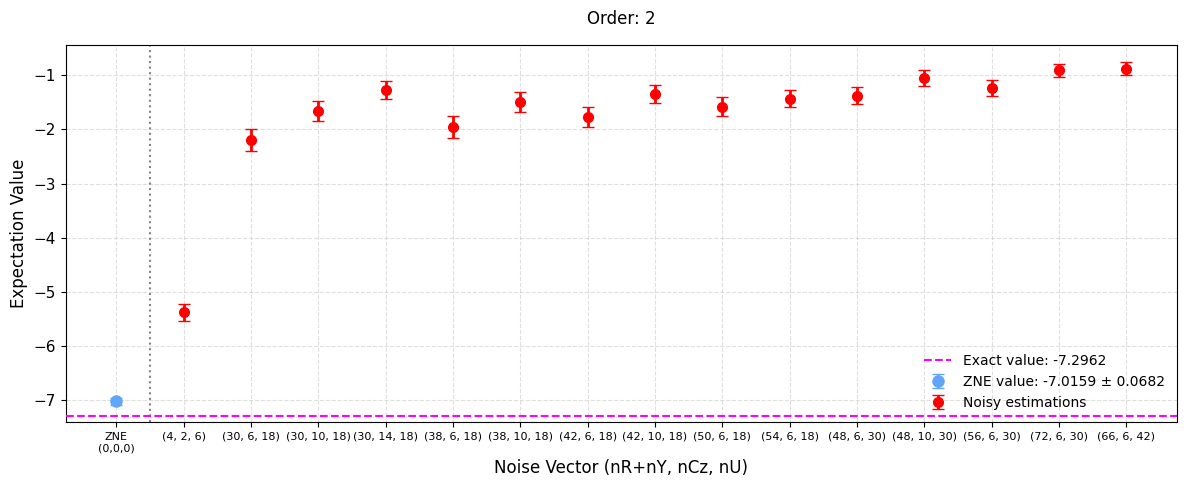

In [ ]:
# Multivariate (3 noise variable vs extrapolated value) Richardson extrapolation of order 1 
ricmul_d2 = process_single_mul(RAW_SIM_DATA["time-depol"]["ZNE"]["mul-var3-d2"])
print(ricmul_d2)
plot_ricmul(ricmul_d2, title = "Order: 2", figsize=(12, 5))

{'mul_data': {'extrapolated': {'mean': -7.116432255135618, 'std': 0.038877389772050165}, 'data_points': {'(102, 6, 42)': {'mean': -0.48440166155574893, 'std': 0.07990627199995591}, '(30, 10, 18)': {'mean': -1.6627783961603604, 'std': 0.19079995369571334}, '(30, 14, 18)': {'mean': -1.276309401868216, 'std': 0.1730783675725983}, '(30, 6, 18)': {'mean': -2.191689527164345, 'std': 0.20196868455618608}, '(4, 2, 6)': {'mean': -5.376872043907548, 'std': 0.15106007040720076}, '(42, 10, 18)': {'mean': -1.346303637933639, 'std': 0.1684381261748081}, '(42, 14, 18)': {'mean': -1.0363223075161698, 'std': 0.15021535900011043}, '(42, 6, 18)': {'mean': -1.7688514544538811, 'std': 0.1834481950351037}, '(48, 10, 30)': {'mean': -1.052067744710349, 'std': 0.14257121194939198}, '(48, 14, 30)': {'mean': -0.811743834422866, 'std': 0.12503358368458592}, '(48, 6, 30)': {'mean': -1.3783590356697188, 'std': 0.1593612532175594}, '(54, 10, 18)': {'mean': -1.093306047108439, 'std': 0.14774640578052795}, '(54, 6, 18

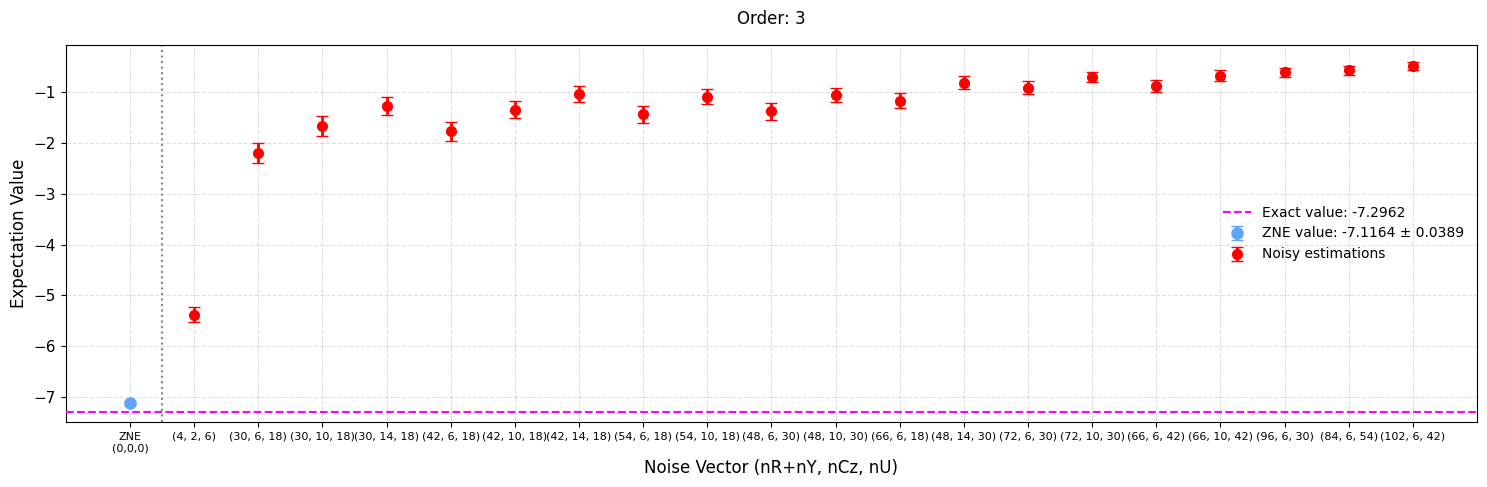

In [ ]:
# Multivariate (3 noise variable vs extrapolated value) Richardson extrapolation of order 1 
ricmul_d2 = process_single_mul(RAW_SIM_DATA["time-depol"]["ZNE"]["mul-var3-d3"])
print(ricmul_d2)
plot_ricmul(ricmul_d2, title = "Order: 3", figsize=(15, 5))